### NB4 — Final QSAR Model Evaluation
### Author: Hamid Bouseber
### Project: COX-2 QSAR-XAI workflow
### Input: PubChem descriptor matrices from NB2
### Output: validation figures, Y-randomization, applicability domain, predictions

## 1. Imports and global configuration

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.neighbors import NearestNeighbors

In [2]:
# ============================================================
# Paths
# ============================================================

MATRICES_DIR = "./matrices"
RESULTS_DIR = "./results"
FIGURES_DIR = "./figures"
FONT_DIR = "./fonts"

Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)
Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)

# ============================================================
# Model and validation settings
# ============================================================

N_ESTIMATORS = 300
RANDOM_STATE = 42
TEST_SIZE = 0.20

N_PERMUTATIONS = 100
AD_K = 5
AD_PERCENTILE = 95

# ============================================================
# Figure settings
# ============================================================

DPI = 600
FONT_SIZE = 8
FIG_FORMATS = ["png", "tif", "eps"]

## 2. Journal-style plotting functions

In [4]:
# ============================================================
# Arial font
# ============================================================

font_path = Path(FONT_DIR) / "arial.ttf"

if font_path.exists():
    fm.fontManager.addfont(str(font_path))
    arial_name = fm.FontProperties(fname=str(font_path)).get_name()
else:
    # Fallback for systems where Arial is already installed or unavailable.
    arial_name = "Arial"
    print(f"Warning: {font_path} was not found. Matplotlib will try to use Arial if installed.")

plt.rcParams.update({
    "font.family": arial_name,
    "font.size": FONT_SIZE,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "savefig.dpi": DPI,
    "figure.dpi": DPI,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def style_axes(ax):
    """Apply consistent journal-style formatting to a matplotlib axis."""
    ax.tick_params(
        axis="both",
        labelsize=8,
        width=1.0,
        length=3
    )

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)

    ax.grid(False)

def save_figure(fig, name, dpi=600):
    """
    Save figures in PNG and TIFF formats.
    """

    png_path = f"{FIGURES_DIR}/{name}.png"
    tiff_path = f"{FIGURES_DIR}/{name}.tiff"

    fig.savefig(
        png_path,
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white"
    )

    fig.savefig(
        tiff_path,
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white"
    )

    print(f"Saved: {png_path}")
    print(f"Saved: {tiff_path}")
    

## 3. Helper functions

In [5]:
def regression_metrics(y_true, y_pred):
    """Return standard regression metrics."""
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }


def safe_metrics(y_true, y_pred):
    """Return metrics; use NaN for R2 when fewer than two samples are available."""
    if len(y_true) < 2:
        return {"R2": np.nan, "RMSE": np.nan, "MAE": np.nan}

    return regression_metrics(y_true, y_pred)


def make_rf():
    """Build the optimized Random Forest model used in the final validation."""
    return RandomForestRegressor(
        n_estimators=N_ESTIMATORS,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

## 4. Load descriptor matrices

In [6]:
# ============================================================
# Load PubChem fingerprint matrices
# ============================================================

X = pd.read_csv(f"{MATRICES_DIR}/X_pubchem_train_test.csv")
y = pd.read_csv(f"{MATRICES_DIR}/y_train_test.csv").iloc[:, 0].astype(float)

X_external = pd.read_csv(f"{MATRICES_DIR}/X_pubchem_external.csv")
y_external = pd.read_csv(f"{MATRICES_DIR}/y_external.csv").iloc[:, 0].astype(float)

assert list(X.columns) == list(X_external.columns), (
    "Train/test and external descriptor columns are not aligned."
)

print("Train/test matrix:", X.shape)
print("External matrix  :", X_external.shape)

Train/test matrix: (2297, 481)
External matrix  : (58, 481)


## 5. Train optimized QSAR model

The internal model is trained on the train split and evaluated on the test split.  
The final model is refitted using the complete train/test dataset and used for external validation.

In [7]:
# ============================================================
# Internal train/test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

# Internal model for test-set validation
model_internal = make_rf()
model_internal.fit(X_train, y_train)

pred_train = model_internal.predict(X_train)
pred_test = model_internal.predict(X_test)

# Final model for external validation
model_final = make_rf()
model_final.fit(X, y)

pred_full = model_final.predict(X)
pred_external = model_final.predict(X_external)

# Summary metrics
metrics_summary = pd.DataFrame([
    {"Dataset": "Train", **regression_metrics(y_train, pred_train), "n": len(y_train)},
    {"Dataset": "Test", **regression_metrics(y_test, pred_test), "n": len(y_test)},
    {"Dataset": "External", **regression_metrics(y_external, pred_external), "n": len(y_external)}
]).round(3)

metrics_summary.to_csv(
    f"{RESULTS_DIR}/NB4_model_validation_metrics.csv",
    index=False
)

metrics_summary

,Dataset,R2,RMSE,MAE,n
0,Train,0.928,0.336,0.225,1837
1,Test,0.653,0.753,0.527,460
2,External,0.509,0.416,0.350,58


## 6. Figure 2 — Experimental versus predicted pIC$_{50}$

Saved: ./figures/Figure2_Test_External_Experimental_vs_Predicted.png
Saved: ./figures/Figure2_Test_External_Experimental_vs_Predicted.tiff


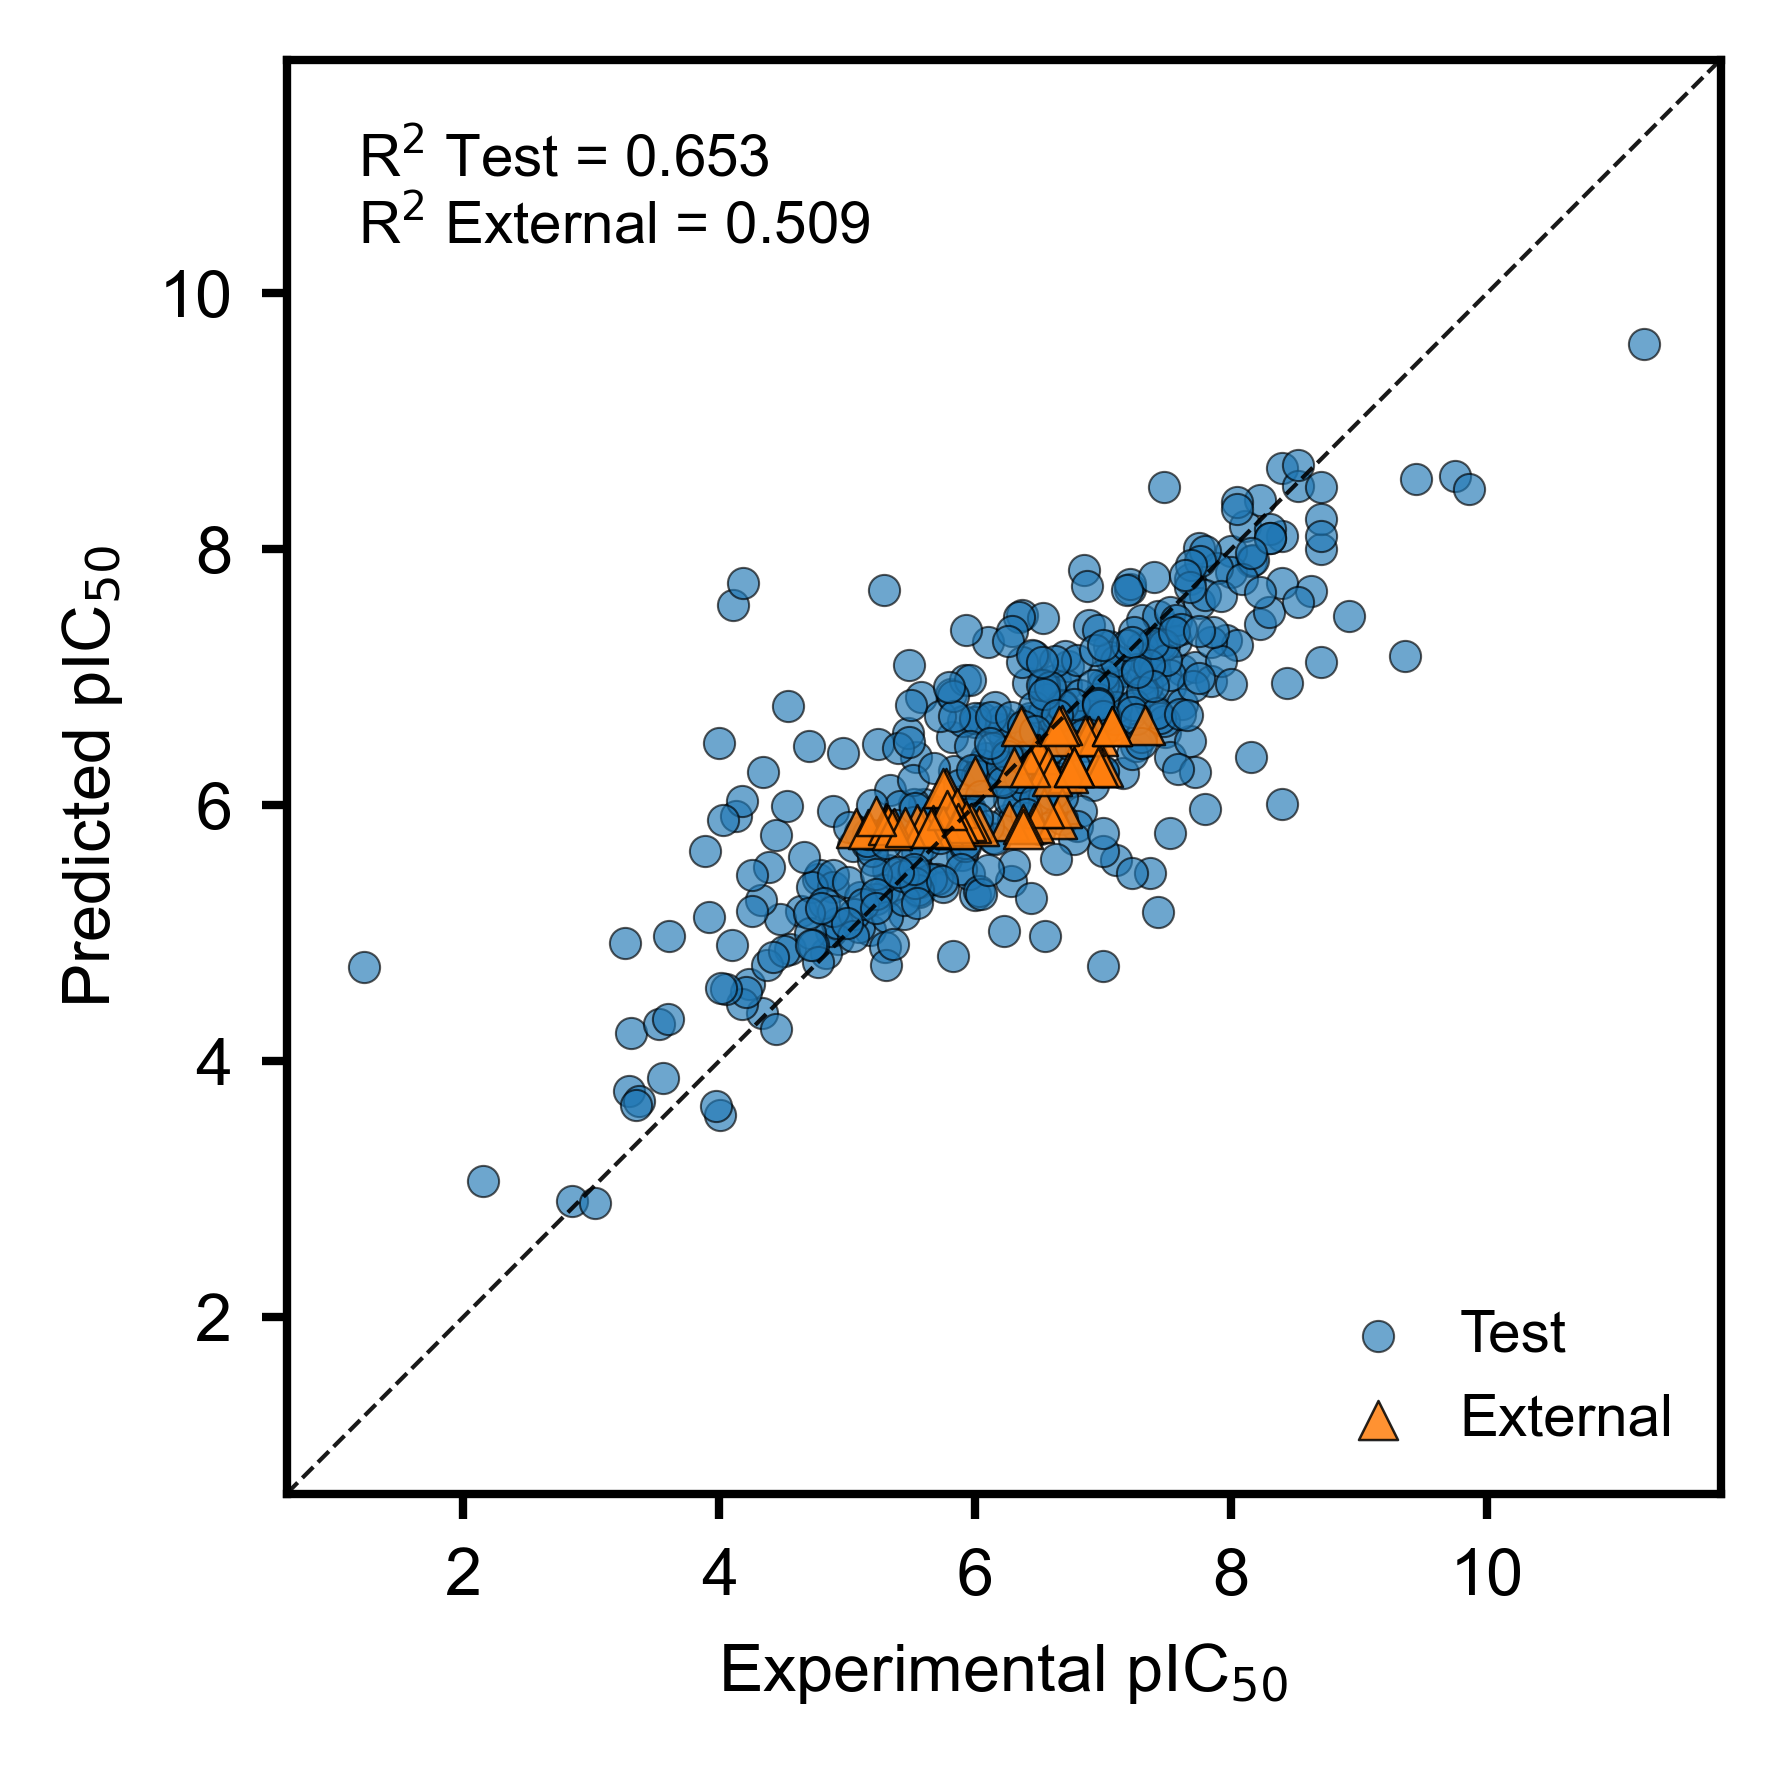

In [8]:
# ============================================================
# Figure 2 — Experimental vs Predicted pIC50
# ============================================================

all_true = np.concatenate([y_test.values, y_external.values])
all_pred = np.concatenate([pred_test, pred_external])

vmin = min(all_true.min(), all_pred.min())
vmax = max(all_true.max(), all_pred.max())
pad = 0.06 * (vmax - vmin)
lims = (vmin - pad, vmax + pad)

r2_test = r2_score(y_test.values, pred_test)
r2_external = r2_score(y_external.values, pred_external)

metric_text = (
    f"R$^2$ Test = {r2_test:.3f}\n"
    f"R$^2$ External = {r2_external:.3f}"
)

fig, ax = plt.subplots(
    figsize=(3.0, 3.0),
    dpi=DPI,
    facecolor="white"
)

ax.scatter(
    y_test.values,
    pred_test,
    s=14,
    marker="o",
    alpha=0.65,
    edgecolor="black",
    linewidth=0.25,
    label="Test"
)

ax.scatter(
    y_external.values,
    pred_external,
    s=22,
    marker="^",
    alpha=0.85,
    edgecolor="black",
    linewidth=0.30,
    label="External"
)

ax.plot(
    lims,
    lims,
    linestyle="--",
    linewidth=0.5,
    color="black",
    alpha=0.9
)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Experimental pIC$_{50}$", fontsize=8)
ax.set_ylabel("Predicted pIC$_{50}$", fontsize=8)

ax.text(
    0.05,
    0.95,
    metric_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=7
)

ax.legend(
    frameon=False,
    fontsize=7,
    loc="lower right",
    handletextpad=0.4,
    borderaxespad=0.4
)

style_axes(ax)

plt.tight_layout()
save_figure(fig, "Figure2_Test_External_Experimental_vs_Predicted")
plt.show()

Figure 2. Experimental versus predicted pIC$_{50}$ values for the test and external validation sets generated by the optimized QSAR model.

## 7. Y-randomization validation

In [9]:
# ============================================================
# Y-randomization
# ============================================================

rng = np.random.default_rng(RANDOM_STATE)
yrand_rows = []

m_original = regression_metrics(y_test, pred_test)

yrand_rows.append({
    "run": "original",
    "kind": "original",
    "test_R2": m_original["R2"],
    "test_RMSE": m_original["RMSE"],
    "test_MAE": m_original["MAE"]
})

for i in range(N_PERMUTATIONS):
    y_perm = pd.Series(
        rng.permutation(y_train.values),
        index=y_train.index
    )

    perm_model = make_rf()
    perm_model.fit(X_train, y_perm)

    pred_perm = perm_model.predict(X_test)
    m_perm = regression_metrics(y_test, pred_perm)

    yrand_rows.append({
        "run": f"perm_{i + 1:03d}",
        "kind": "permuted",
        "test_R2": m_perm["R2"],
        "test_RMSE": m_perm["RMSE"],
        "test_MAE": m_perm["MAE"]
    })

df_yrand = pd.DataFrame(yrand_rows)
df_yrand.to_csv(
    f"{RESULTS_DIR}/y_randomization_results.csv",
    index=False
)

df_perm = df_yrand[df_yrand["kind"] == "permuted"].copy()
df_orig = df_yrand[df_yrand["kind"] == "original"].copy()

df_yrand_summary = pd.DataFrame([{
    "original_R2": df_orig["test_R2"].iloc[0],
    "permuted_R2_mean": df_perm["test_R2"].mean(),
    "permuted_R2_max": df_perm["test_R2"].max(),
    "original_RMSE": df_orig["test_RMSE"].iloc[0],
    "permuted_RMSE_mean": df_perm["test_RMSE"].mean(),
    "permuted_RMSE_min": df_perm["test_RMSE"].min(),
    "original_MAE": df_orig["test_MAE"].iloc[0],
    "permuted_MAE_mean": df_perm["test_MAE"].mean(),
    "n_permutations": N_PERMUTATIONS
}]).round(3)

df_yrand_summary.to_csv(
    f"{RESULTS_DIR}/y_randomization_summary.csv",
    index=False
)

df_yrand_summary

,original_R2,permuted_R2_mean,permuted_R2_max,original_RMSE,permuted_RMSE_mean,permuted_RMSE_min,original_MAE,permuted_MAE_mean,n_permutations
0,0.653,-0.232,-0.076,0.753,1.418,1.325,0.527,1.114,100


## 8. Figure 3 — Y-randomization

Saved: ./figures/Figure3_Y_randomization.png
Saved: ./figures/Figure3_Y_randomization.tiff


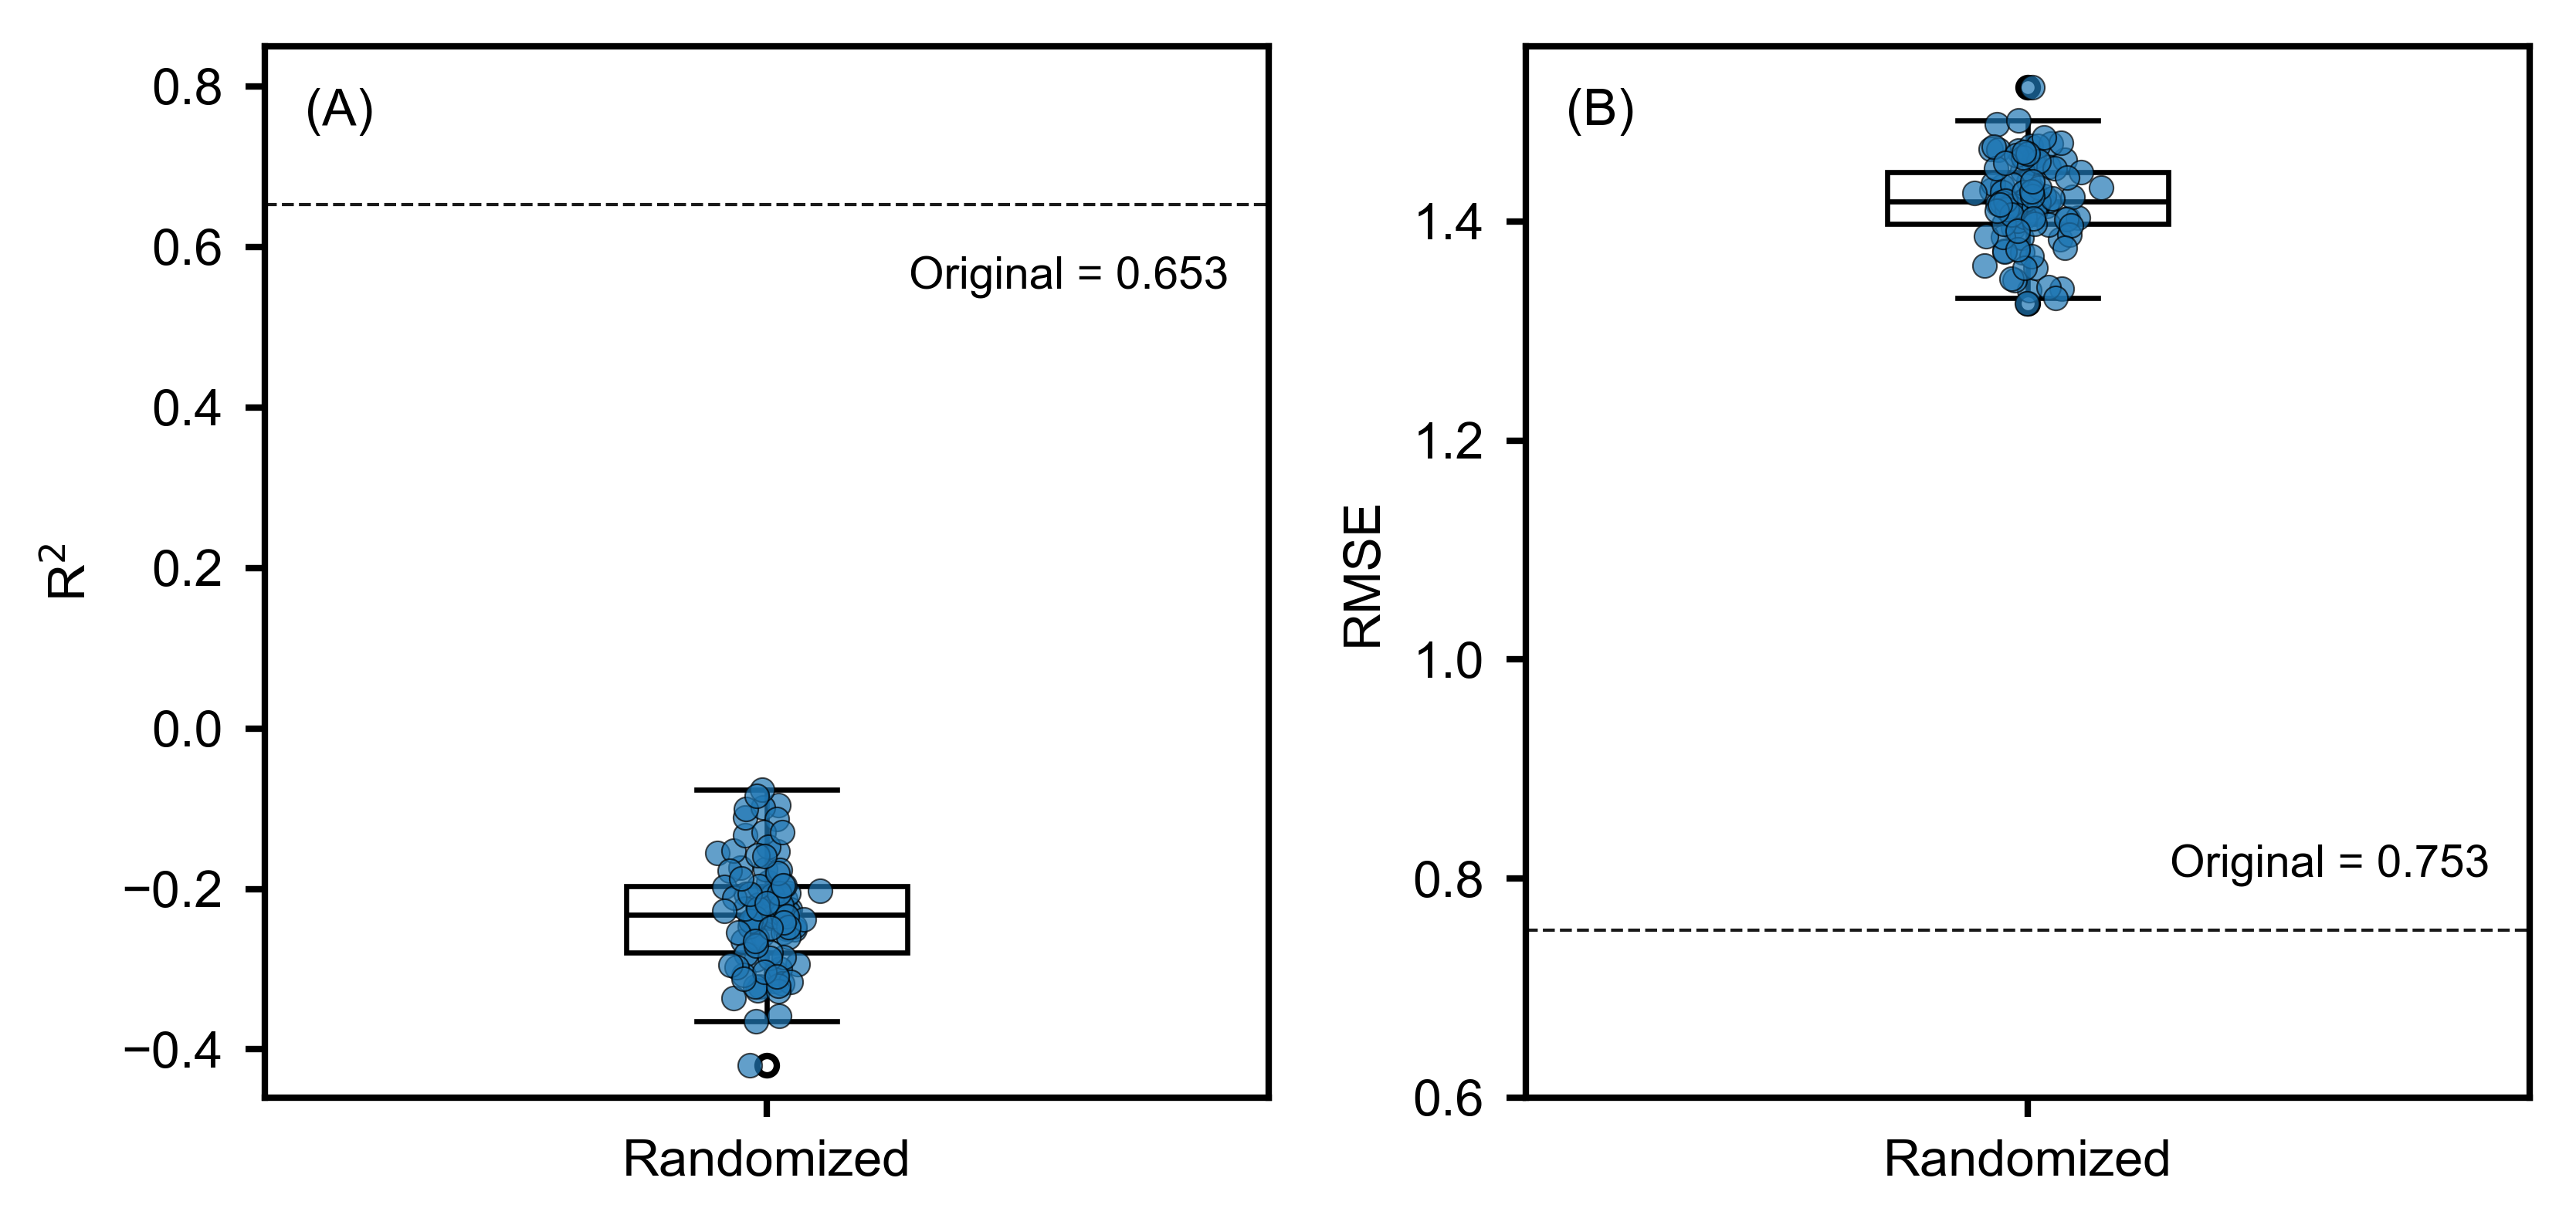

Mean R² (random): -0.2319948185147756
Mean RMSE (random): 1.4175684545715665


In [10]:
# ============================================================
# Figure 3 — Y-randomization
# ============================================================

r2_random_list = df_perm["test_R2"].values
rmse_random_list = df_perm["test_RMSE"].values

original_r2 = df_orig["test_R2"].iloc[0]
original_rmse = df_orig["test_RMSE"].iloc[0]

rng = np.random.default_rng(42)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(5.6, 2.7),
    dpi=DPI,
    facecolor="white"
)

box_style = dict(
    vert=True,
    patch_artist=True,
    widths=0.28,

    boxprops=dict(
        facecolor=(1, 1, 1, 0.35),
        edgecolor="black",
        linewidth=0.8
    ),

    medianprops=dict(
        color="black",
        linewidth=0.8
    ),

    whiskerprops=dict(
        color="black",
        linewidth=0.8
    ),

    capprops=dict(
        color="black",
        linewidth=0.8
    ),

    flierprops=dict(
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=3,
        linestyle="none"
    )
)

# ----------------------------
# (A) R²
# ----------------------------
axes[0].boxplot(r2_random_list, **box_style)

axes[0].scatter(
    rng.normal(1, 0.025, size=len(r2_random_list)),
    r2_random_list,
    s=14,
    marker="o",
    alpha=0.70,
    edgecolor="black",
    linewidth=0.25,
    zorder=3
)

axes[0].axhline(
    original_r2,
    linestyle="--",
    linewidth=0.5,
    color="black",
    alpha=0.9,
    zorder=1
)

axes[0].set_ylim(-0.46, 0.85)
axes[0].set_xticks([1])
axes[0].set_xticklabels(["Randomized"], fontsize=8)
axes[0].set_ylabel("R$^2$", fontsize=8)

axes[0].text(
    0.04,
    0.96,
    "(A)",
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=8
)

axes[0].text(
    0.96,
    0.80,
    f"Original = {original_r2:.3f}",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    fontsize=7
)

# ----------------------------
# (B) RMSE
# ----------------------------
axes[1].boxplot(rmse_random_list, **box_style)

axes[1].scatter(
    rng.normal(1, 0.025, size=len(rmse_random_list)),
    rmse_random_list,
    s=14,
    marker="o",
    alpha=0.70,
    edgecolor="black",
    linewidth=0.25,
    zorder=3
)

axes[1].axhline(
    original_rmse,
    linestyle="--",
    linewidth=0.5,
    color="black",
    alpha=0.9,
    zorder=1
)

axes[1].set_ylim(0.60, 1.56)
axes[1].set_xticks([1])
axes[1].set_xticklabels(["Randomized"], fontsize=8)
axes[1].set_ylabel("RMSE", fontsize=8)

axes[1].text(
    0.04,
    0.96,
    "(B)",
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=8
)

axes[1].text(
    0.96,
    0.20,
    f"Original = {original_rmse:.3f}",
    transform=axes[1].transAxes,
    ha="right",
    va="bottom",
    fontsize=7
)

for ax in axes:
    style_axes(ax)

plt.tight_layout(w_pad=1.4)
save_figure(fig, "Figure3_Y_randomization")
plt.show()

print("Mean R² (random):", np.mean(r2_random_list))
print("Mean RMSE (random):", np.mean(rmse_random_list))

Figure 3. Y-randomization analysis of the optimized QSAR model using randomized response values, showing the distributions of R$^2$ and RMSE compared with the original model performance.

## 9. Applicability domain analysis

In [11]:
# ============================================================
# Applicability Domain analysis
# ============================================================

X_train_bool = X_train.astype(bool)
X_test_bool = X_test.astype(bool)
X_external_bool = X_external.astype(bool)

# Distance distribution within the training set
nn_train = NearestNeighbors(
    n_neighbors=AD_K + 1,
    metric="jaccard"
)

nn_train.fit(X_train_bool)

dist_train, _ = nn_train.kneighbors(X_train_bool)
mean_dist_train = dist_train[:, 1:].mean(axis=1)

ad_threshold = np.percentile(mean_dist_train, AD_PERCENTILE)
ad_threshold_mean3sd = mean_dist_train.mean() + 3 * mean_dist_train.std(ddof=0)

# Distances from test/external compounds to the training set
nn_ad = NearestNeighbors(
    n_neighbors=AD_K,
    metric="jaccard"
)

nn_ad.fit(X_train_bool)

dist_test, _ = nn_ad.kneighbors(X_test_bool)
mean_dist_test = dist_test.mean(axis=1)
inside_test = mean_dist_test <= ad_threshold

dist_external, _ = nn_ad.kneighbors(X_external_bool)
mean_dist_external = dist_external.mean(axis=1)
inside_external = mean_dist_external <= ad_threshold

# Build AD result table
ad_test = pd.DataFrame({
    "dataset": "test",
    "mean_jaccard_distance": mean_dist_test,
    "inside_AD": inside_test,
    "pIC50_exp": y_test.values,
    "pIC50_pred": pred_test,
    "abs_error": np.abs(y_test.values - pred_test)
})

ad_external = pd.DataFrame({
    "dataset": "external",
    "mean_jaccard_distance": mean_dist_external,
    "inside_AD": inside_external,
    "pIC50_exp": y_external.values,
    "pIC50_pred": pred_external,
    "abs_error": np.abs(y_external.values - pred_external)
})

df_ad = pd.concat(
    [ad_test, ad_external],
    ignore_index=True
)

df_ad["threshold_95_percentile"] = ad_threshold
df_ad["threshold_mean_plus_3sd"] = ad_threshold_mean3sd

df_ad.to_csv(
    f"{RESULTS_DIR}/applicability_domain_results.csv",
    index=False
)

# Coverage and error summary
ad_error_summary = (
    df_ad
    .groupby(["dataset", "inside_AD"])
    .agg(
        n=("abs_error", "size"),
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mean_distance=("mean_jaccard_distance", "mean")
    )
    .reset_index()
)

ad_coverage_summary = pd.DataFrame([
    {
        "dataset": "test",
        "n": len(inside_test),
        "inside_AD": int(inside_test.sum()),
        "outside_AD": int((~inside_test).sum()),
        "coverage_percent": 100 * inside_test.mean(),
        "threshold_95_percentile": ad_threshold,
        "threshold_mean_plus_3sd": ad_threshold_mean3sd
    },
    {
        "dataset": "external",
        "n": len(inside_external),
        "inside_AD": int(inside_external.sum()),
        "outside_AD": int((~inside_external).sum()),
        "coverage_percent": 100 * inside_external.mean(),
        "threshold_95_percentile": ad_threshold,
        "threshold_mean_plus_3sd": ad_threshold_mean3sd
    }
])

# Performance inside/outside AD
performance_rows = []

for dataset_name, df_tmp in df_ad.groupby("dataset"):
    for status, df_part in df_tmp.groupby("inside_AD"):
        m = safe_metrics(
            df_part["pIC50_exp"].values,
            df_part["pIC50_pred"].values
        )

        performance_rows.append({
            "dataset": dataset_name,
            "inside_AD": status,
            "n": len(df_part),
            "R2": m["R2"],
            "RMSE": m["RMSE"],
            "MAE": m["MAE"]
        })

ad_performance = pd.DataFrame(performance_rows)

# Threshold sensitivity analysis
sensitivity_rows = []

for percentile in [90, 95, 97.5]:
    threshold = np.percentile(mean_dist_train, percentile)

    for dataset_name, distances, y_true, y_pred in [
        ("test", mean_dist_test, y_test.values, pred_test),
        ("external", mean_dist_external, y_external.values, pred_external)
    ]:
        mask = distances <= threshold
        m = safe_metrics(y_true[mask], y_pred[mask])

        sensitivity_rows.append({
            "threshold_type": f"{percentile}th percentile",
            "threshold": threshold,
            "dataset": dataset_name,
            "n_inside": int(mask.sum()),
            "coverage_percent": 100 * mask.mean(),
            "R2_inside": m["R2"],
            "RMSE_inside": m["RMSE"],
            "MAE_inside": m["MAE"]
        })

ad_sensitivity = pd.DataFrame(sensitivity_rows)

# Save AD tables
ad_error_summary.to_csv(
    f"{RESULTS_DIR}/applicability_domain_error_summary.csv",
    index=False
)

ad_coverage_summary.to_csv(
    f"{RESULTS_DIR}/applicability_domain_coverage_summary.csv",
    index=False
)

ad_performance.to_csv(
    f"{RESULTS_DIR}/applicability_domain_performance_inside_outside.csv",
    index=False
)

ad_sensitivity.to_csv(
    f"{RESULTS_DIR}/applicability_domain_threshold_sensitivity.csv",
    index=False
)

print("AD threshold, 95th percentile:", round(ad_threshold, 3))
print("Alternative threshold, mean + 3SD:", round(ad_threshold_mean3sd, 3))

display(ad_coverage_summary.round(3))
display(ad_error_summary.round(3))
display(ad_performance.round(3))
display(ad_sensitivity.round(3))

AD threshold, 95th percentile: 0.226
Alternative threshold, mean + 3SD: 0.298


,dataset,n,inside_AD,outside_AD,coverage_percent,threshold_95_percentile,threshold_mean_plus_3sd
0,test,460,439,21,95.435,0.226,0.298
1,external,58,58,0,100.000,0.226,0.298


,dataset,inside_AD,n,mean_abs_error,median_abs_error,mean_distance
0,external,True,58,0.350,0.371,0.113
1,test,False,21,0.765,0.763,0.295
2,test,True,439,0.516,0.354,0.073


,dataset,inside_AD,n,R2,RMSE,MAE
0,external,True,58,0.509,0.416,0.350
1,test,False,21,0.649,0.862,0.765
2,test,True,439,0.643,0.747,0.516


,threshold_type,threshold,dataset,n_inside,coverage_percent,R2_inside,RMSE_inside,MAE_inside
0,90th percentile,0.177,test,414,90.000,0.643,0.755,0.520
1,90th percentile,0.177,external,45,77.586,0.486,0.409,0.348
2,95th percentile,0.226,test,439,95.435,0.643,0.747,0.516
3,95th percentile,0.226,external,58,100.000,0.509,0.416,0.350
4,97.5th percentile,0.275,test,450,97.826,0.650,0.751,0.523
5,97.5th percentile,0.275,external,58,100.000,0.509,0.416,0.350


## 10. Figure 4 — Applicability domain

Saved: ./figures/Figure4_ApplicabilityDomain.png
Saved: ./figures/Figure4_ApplicabilityDomain.tiff


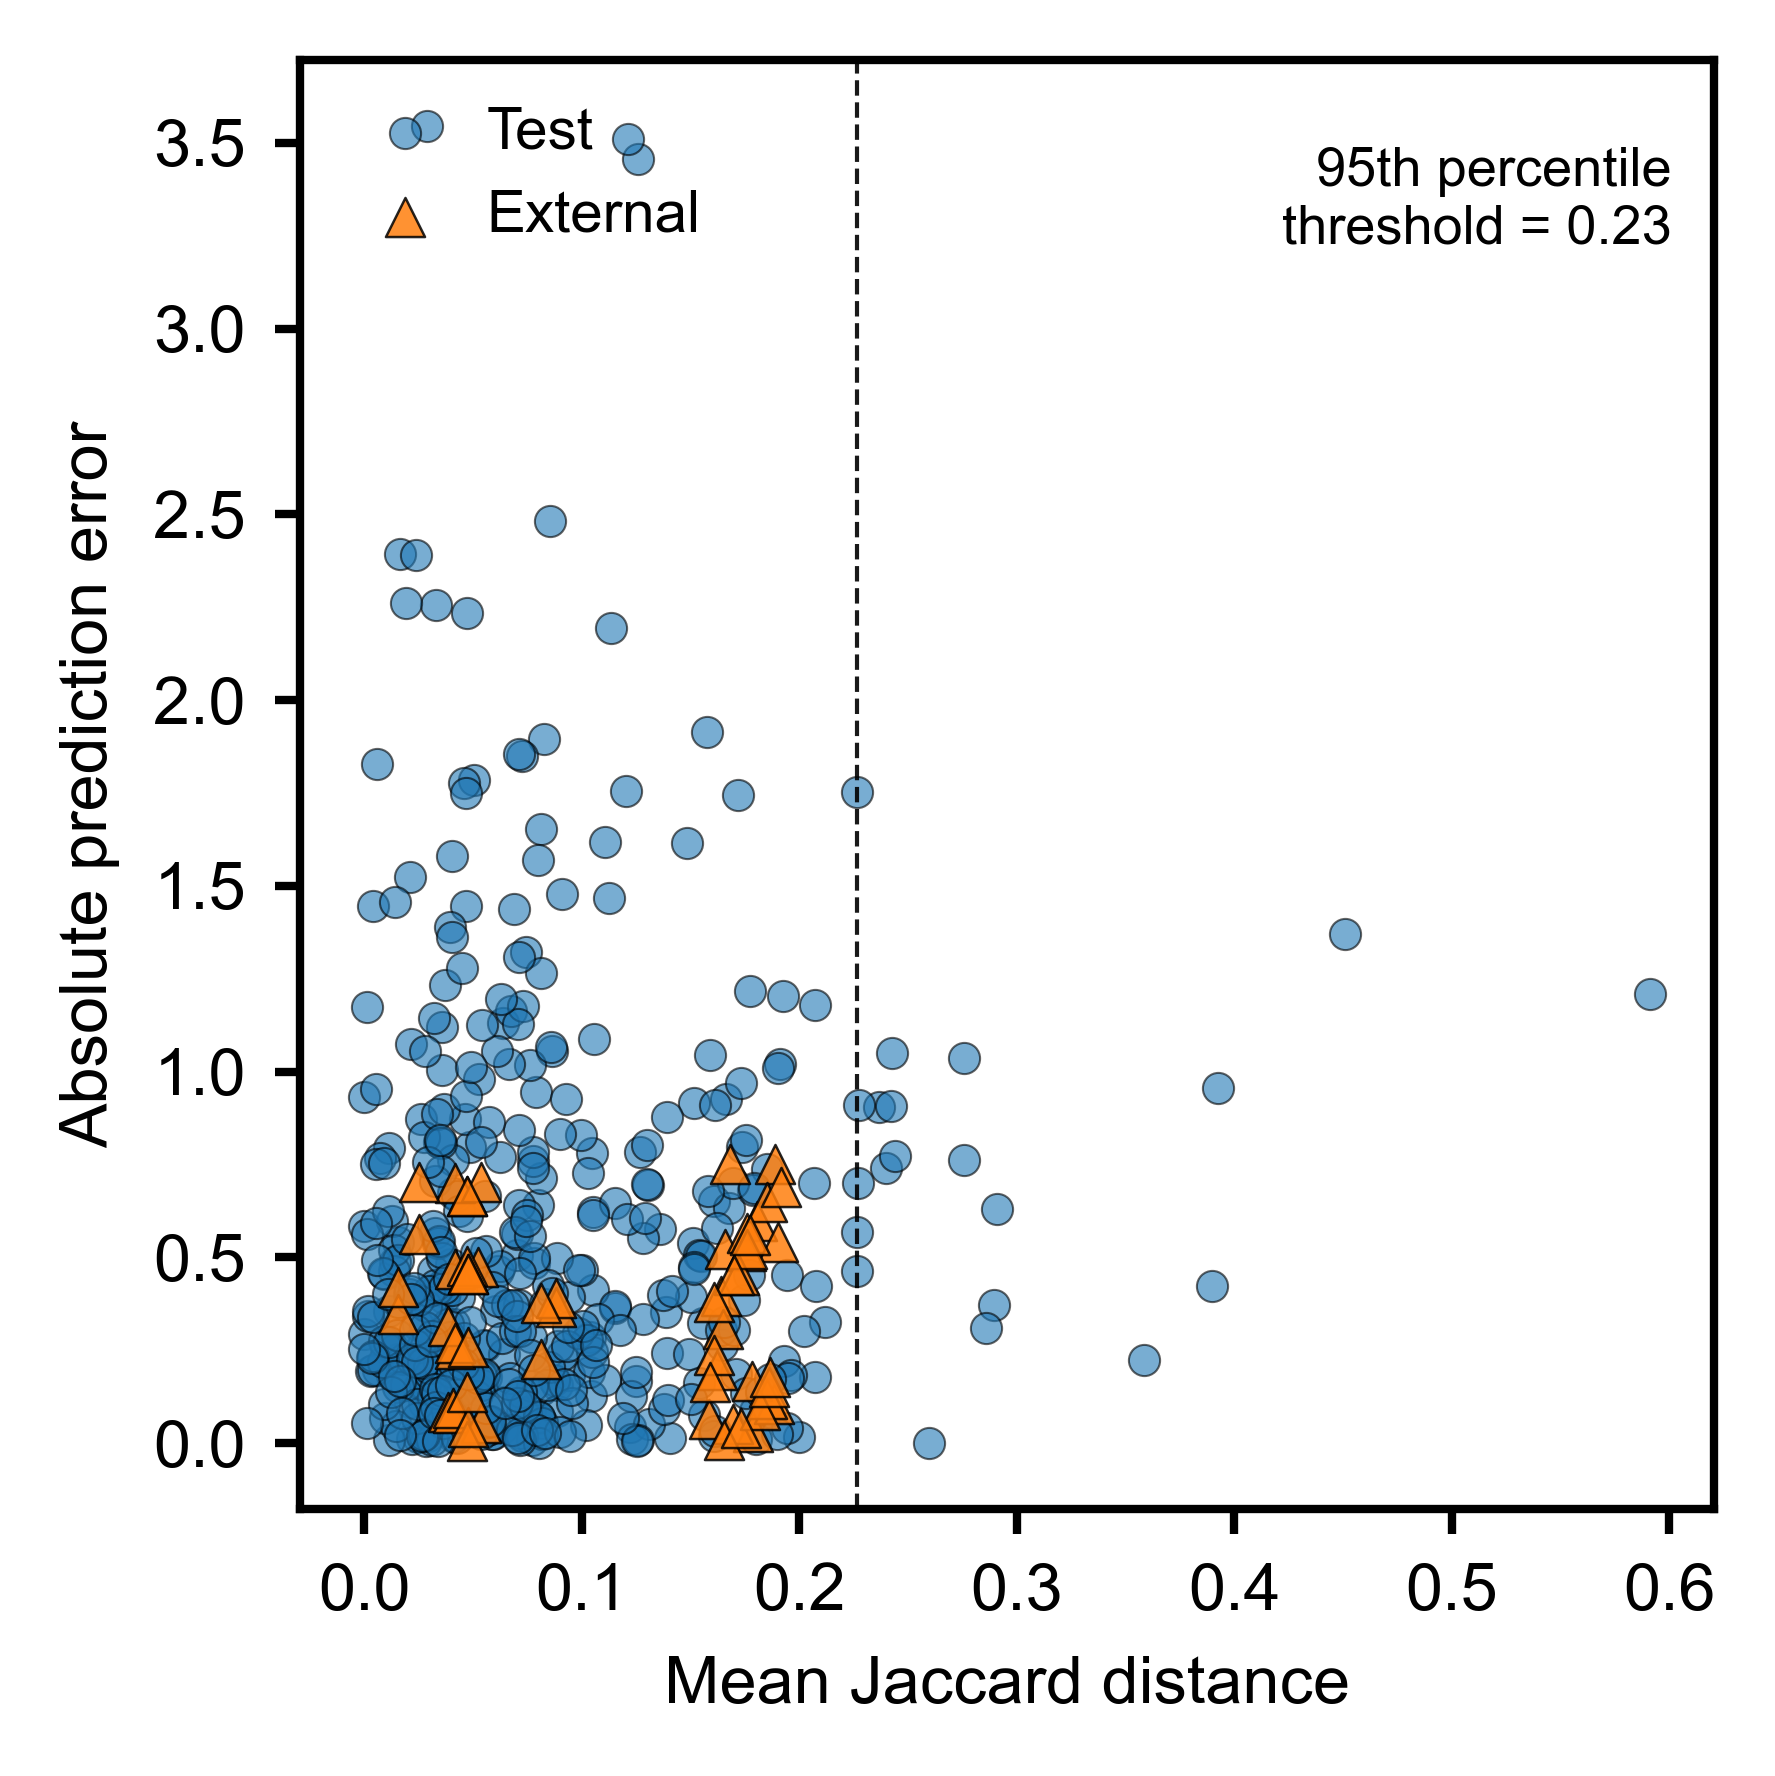

In [12]:
# ============================================================
# Figure 4 — Applicability Domain
# Coherent style with Figures 2 and 3
# ============================================================

fig, ax = plt.subplots(
    figsize=(3.0, 3.0),
    dpi=DPI,
    facecolor="white"
)

ax.scatter(
    mean_dist_test,
    np.abs(y_test.values - pred_test),
    s=14,
    marker="o",
    alpha=0.60,
    edgecolor="black",
    linewidth=0.25,
    label="Test"
)

ax.scatter(
    mean_dist_external,
    np.abs(y_external.values - pred_external),
    s=22,
    marker="^",
    alpha=0.85,
    edgecolor="black",
    linewidth=0.30,
    label="External"
)

ax.axvline(
    ad_threshold,
    linestyle="--",
    linewidth=0.5,
    color="black",
    alpha=0.9
)

ax.set_xlabel("Mean Jaccard distance", fontsize=8)
ax.set_ylabel("Absolute prediction error", fontsize=8)

ax.text(
    0.97,
    0.94,
    f"95th percentile\nthreshold = {ad_threshold:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=6.5
)

ax.legend(
    frameon=False,
    fontsize=7,
    loc="upper left",
    handletextpad=0.4,
    borderaxespad=0.4
)

style_axes(ax)

plt.tight_layout()
save_figure(fig, "Figure4_ApplicabilityDomain")
plt.show()

Figure 4. Applicability domain analysis of the optimized QSAR model based on mean Jaccard distance and absolute prediction error for the test and external validation sets. The vertical dashed line represents the 95th percentile applicability domain threshold.

## 11. Export predictions

In [13]:
# ============================================================
# Save final predictions
# ============================================================

pd.DataFrame({
    "dataset": "train",
    "pIC50_exp": y_train.values,
    "pIC50_pred": pred_train
}).to_csv(
    f"{RESULTS_DIR}/NB4_predictions_train.csv",
    index=False
)

pd.DataFrame({
    "dataset": "test",
    "pIC50_exp": y_test.values,
    "pIC50_pred": pred_test
}).to_csv(
    f"{RESULTS_DIR}/NB4_predictions_test.csv",
    index=False
)

pd.DataFrame({
    "dataset": "external",
    "pIC50_exp": y_external.values,
    "pIC50_pred": pred_external
}).to_csv(
    f"{RESULTS_DIR}/NB4_predictions_external.csv",
    index=False
)

print("Prediction files saved.")

Prediction files saved.


## 12. Final output check

In [14]:
# ============================================================
# Final output check
# ============================================================

required_files = [
    "NB4_model_validation_metrics.csv",
    "NB4_predictions_train.csv",
    "NB4_predictions_test.csv",
    "NB4_predictions_external.csv",
    "y_randomization_results.csv",
    "y_randomization_summary.csv",
    "applicability_domain_results.csv",
    "applicability_domain_error_summary.csv",
    "applicability_domain_coverage_summary.csv",
    "applicability_domain_performance_inside_outside.csv",
    "applicability_domain_threshold_sensitivity.csv",
]

for file in required_files:
    path = Path(RESULTS_DIR) / file
    assert path.exists(), f"Missing output: {path}"

print("NB4 completed successfully.")
print("Figures saved in:", FIGURES_DIR)
print("Results saved in:", RESULTS_DIR)

NB4 completed successfully.
Figures saved in: ./figures
Results saved in: ./results
